<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
!pip install seaborn

In [5]:
import seaborn as sns

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2026-01-21 04:14:59--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  58.4MB/s    in 2.6s    

2026-01-21 04:15:02 (58.4 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots

#### 1. Bubble Plot for Age vs. Frequency of Participation

- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.
- Use the size of the bubbles to represent their job satisfaction (`JobSat`).

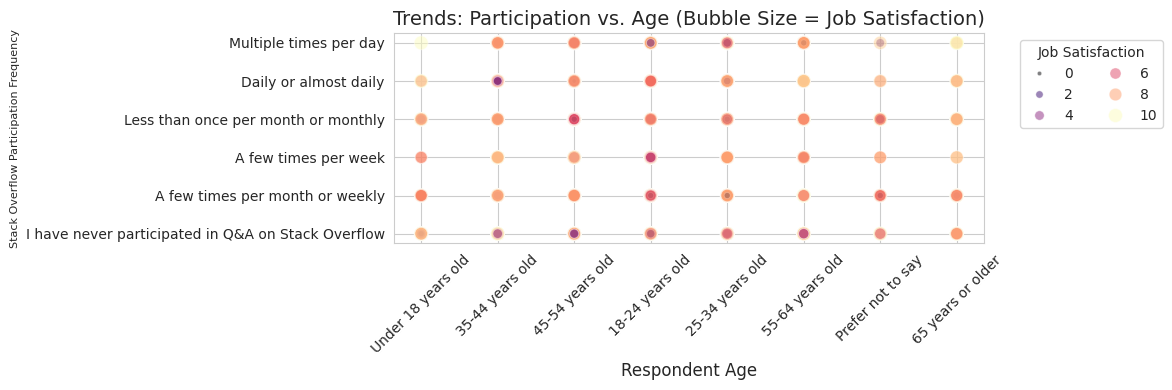

In [12]:
##Write your code here
# Setup the figure
plt.figure(figsize=(12, 4))
sns.set_style("whitegrid")

bubble = sns.scatterplot(data=df, x='Age', y='SOPartFreq', size='JobSat', sizes=(10, 100), hue='JobSat', alpha=0.5, palette='magma')

# Formatting
plt.title('Trends: Participation vs. Age (Bubble Size = Job Satisfaction)', fontsize=14)
plt.xticks(rotation=45)
plt.xlabel('Respondent Age', fontsize=12)
plt.ylabel('Stack Overflow Participation Frequency', fontsize=8)
# Legend Configuration (2-column layout)
plt.legend(title='Job Satisfaction', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


In [13]:
df_new = df[['ConvertedCompYearly','JobSat','Age']]
df_new.head()

,ConvertedCompYearly,JobSat,Age
0,NaN,NaN,Under 18 years old
1,NaN,NaN,35-44 years old
2,NaN,NaN,45-54 years old
3,NaN,NaN,18-24 years old
4,NaN,NaN,18-24 years old


In [14]:
##Write your code here
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None  # This will be dropped for regression
}

# Create a new numeric column
df_new['Age_Numeric'] = df_new['Age'].map(age_mapping)

/tmp/ipykernel_4189/1145058072.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['Age_Numeric'] = df_new['Age'].map(age_mapping)


In [15]:
df_new['ConvertedCompYearly'] = pd.to_numeric(df_new['ConvertedCompYearly'], errors = 'coerce')
df_new['JobSat'] = pd.to_numeric(df_new['JobSat'], errors = 'coerce')

/tmp/ipykernel_4189/3166581116.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['ConvertedCompYearly'] = pd.to_numeric(df_new['ConvertedCompYearly'], errors = 'coerce')
/tmp/ipykernel_4189/3166581116.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['JobSat'] = pd.to_numeric(df_new['JobSat'], errors = 'coerce')


In [17]:
# Keep data between the 1st and 99th percentile
lower_limit = df_new['ConvertedCompYearly'].quantile(0.01)
upper_limit = df_new['ConvertedCompYearly'].quantile(0.99)
df_new = df_new[(df_new['ConvertedCompYearly'] > lower_limit) & (df_new['ConvertedCompYearly'] < upper_limit)]

In [25]:
df_new = df_new.dropna(subset=['ConvertedCompYearly', 'JobSat', 'Age_Numeric'])

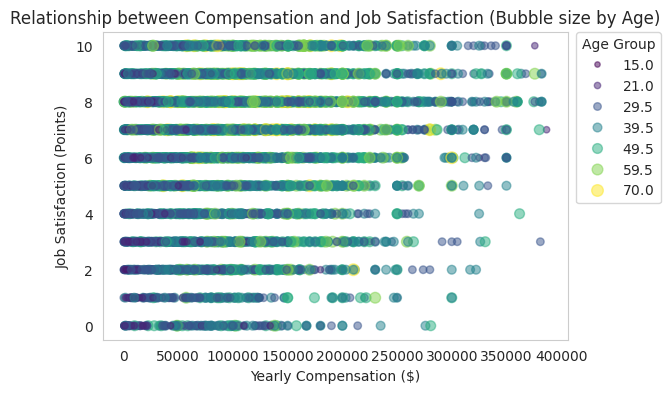

In [26]:
plt.figure(figsize=(6, 4))
scatter = plt.scatter(
    df_new['ConvertedCompYearly'],
    df_new['JobSat'],
    s=df_new['Age_Numeric'], # Scale age for better visibility of bubble sizes
    alpha=0.5,
    c=df_new['Age_Numeric'], # Optional: color by age as well
    cmap='viridis'
)
# Add labels and title
plt.title('Relationship between Compensation and Job Satisfaction (Bubble size by Age)')
plt.xlabel('Yearly Compensation ($)')
plt.ylabel('Job Satisfaction (Points)')
# Add a legend for size
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
for handle, label in zip(handles, labels):
    # Parse the numeric value from the label (e.g., '40' from the text)
    val = float(label.replace('$\\mathdefault{', '').replace('}$', ''))
    color = scatter.cmap(scatter.norm(val))
    handle.set_color(color)
    
plt.legend(handles, labels, loc="upper right", title="Age Group", facecolor='inherit', bbox_to_anchor=(1.2, 1), borderaxespad=0.)
plt.grid(False)
plt.show() # Use plt.show() to display the plot

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



In [27]:
##Write your code here
df_lang = df.assign(Language=df['LanguageHaveWorkedWith'].str.split(';')).explode('Language')

In [29]:
# 2. Calculate frequencies (Value Counts) per Age and Language
# This creates a summary table with [Age, Language, Count]
bubble_data = df_lang.groupby(['Age', 'Language']).size().reset_index(name='Count')

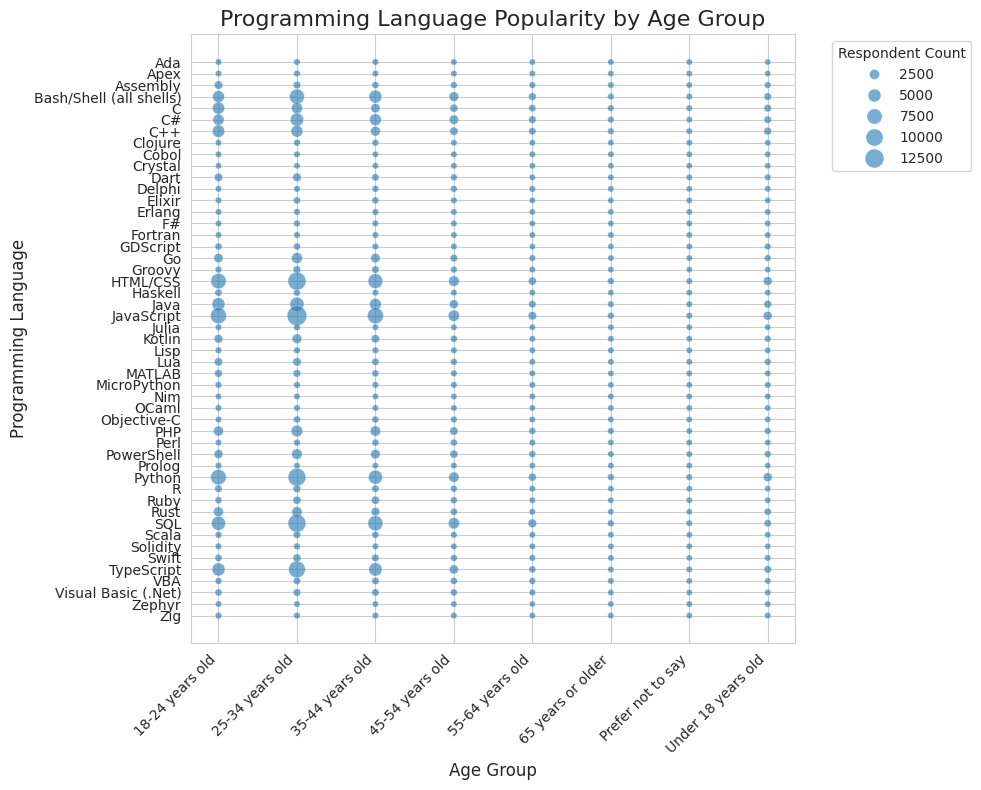

In [34]:
# 3. Create the Bubble Chart
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
# Map 'Count' to the 'size' parameter
# 'sizes' controls the range of bubble diameters
ax = sns.scatterplot(data=bubble_data, x="Age", y="Language", size="Count", sizes=(20, 200), alpha=0.6, legend='brief')
# 4. Final Touches
plt.title("Programming Language Popularity by Age Group", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Programming Language", fontsize=12)
plt.legend(title="Respondent Count", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


In [39]:
df_exploded = df.assign(Database=df['DatabaseWantToWorkWith'].str.split(';')).explode('Database')

In [41]:
bubble_db = df_exploded.groupby(['Database', 'JobSat']).size().reset_index(name='Respondent_Count')

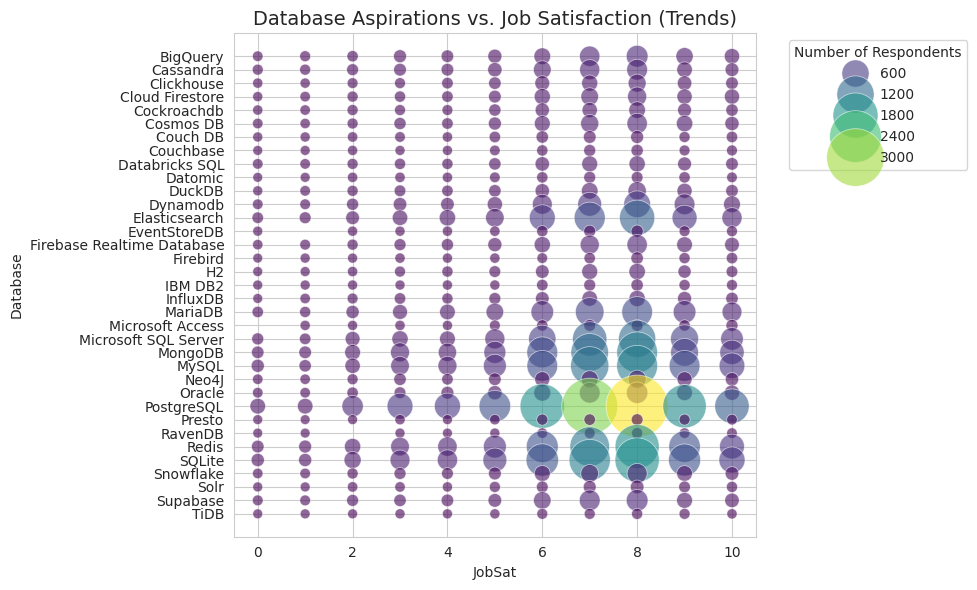

In [48]:
##Write your code here
# 3. Create the Bubble Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# We map 'Respondent_Count' to 'size' to create the bubbles
ax = sns.scatterplot(data=bubble_db, x="JobSat", y="Database", size="Respondent_Count", sizes=(50, 2000), hue="Respondent_Count", palette="viridis", alpha=0.6)

# 4. Formatting
plt.title("Database Aspirations vs. Job Satisfaction (Trends)", fontsize=14)
plt.legend(title="Number of Respondents", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


In [49]:
# 1. Prepare Data: Explode 'DevType' if it contains multiple roles
df_dev = df.assign(DevType=df['DevType'].str.split(';')).explode('DevType')

In [51]:
##Write your code here
# 2. Aggregation: Calculate average compensation and satisfaction per role
# We also count respondents per role to ensure we have a significant sample
bubble_dev = df_dev.groupby('DevType').agg({
    'ConvertedCompYearly': 'median',  # Median is often better for skewed salary data
    'JobSat': 'mean',        # Numeric satisfaction (e.g., 1-5 or 1-10)
    'ResponseId': 'count'             # Optional: use for filtering out rare roles
}).reset_index()

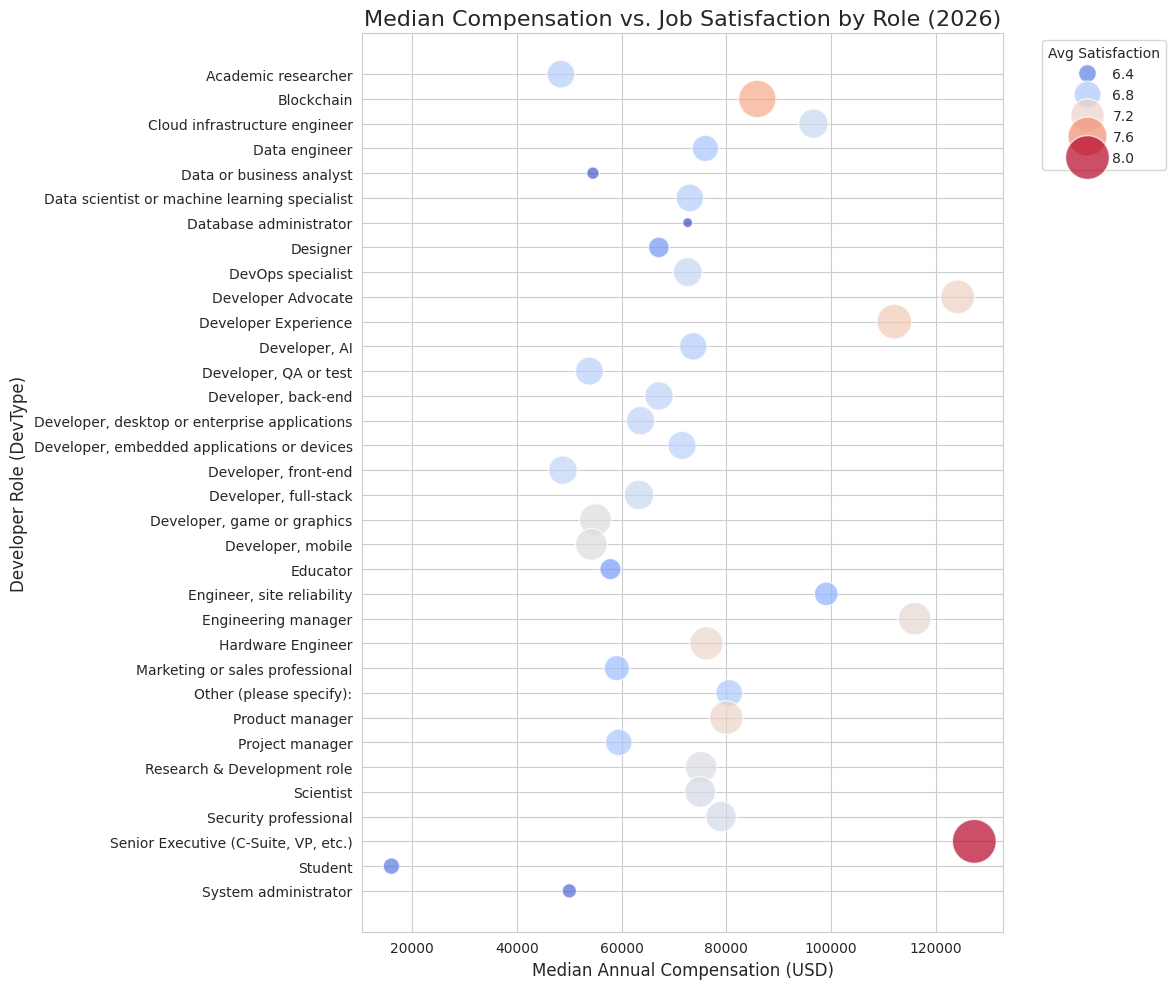

In [53]:
# 3. Create the Bubble Chart
plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

# Plot: x = Compensation, y = Role, size = Satisfaction
ax = sns.scatterplot(
    data=bubble_dev,
    x="ConvertedCompYearly",
    y="DevType",
    size="JobSat",    # Map bubble size to satisfaction
    sizes=(50, 1000),          # Scale the min/max bubble areas
    hue="JobSat",     # Also use color for extra clarity
    palette="coolwarm",        # Red for high satisfaction, blue for low
    alpha=0.7
)

# 4. Formatting
plt.title("Median Compensation vs. Job Satisfaction by Role (2026)", fontsize=16)
plt.xlabel("Median Annual Compensation (USD)", fontsize=12)
plt.ylabel("Developer Role (DevType)", fontsize=12)
plt.legend(title="Avg Satisfaction", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


In [54]:
# 1. Clean and Explode the Collab Tools column
# This creates a separate row for every tool-age combination
df_exploded = df.assign(Tool=df['NEWCollabToolsHaveWorkedWith'].str.split(';')).explode('Tool')

In [55]:
# 2. Calculate Frequencies (Respondent Counts)
# This produces a summary with columns: [Age, Tool, UsageCount]
collab_counts = df_exploded.groupby(['Age', 'Tool']).size().reset_index(name='UsageCount')

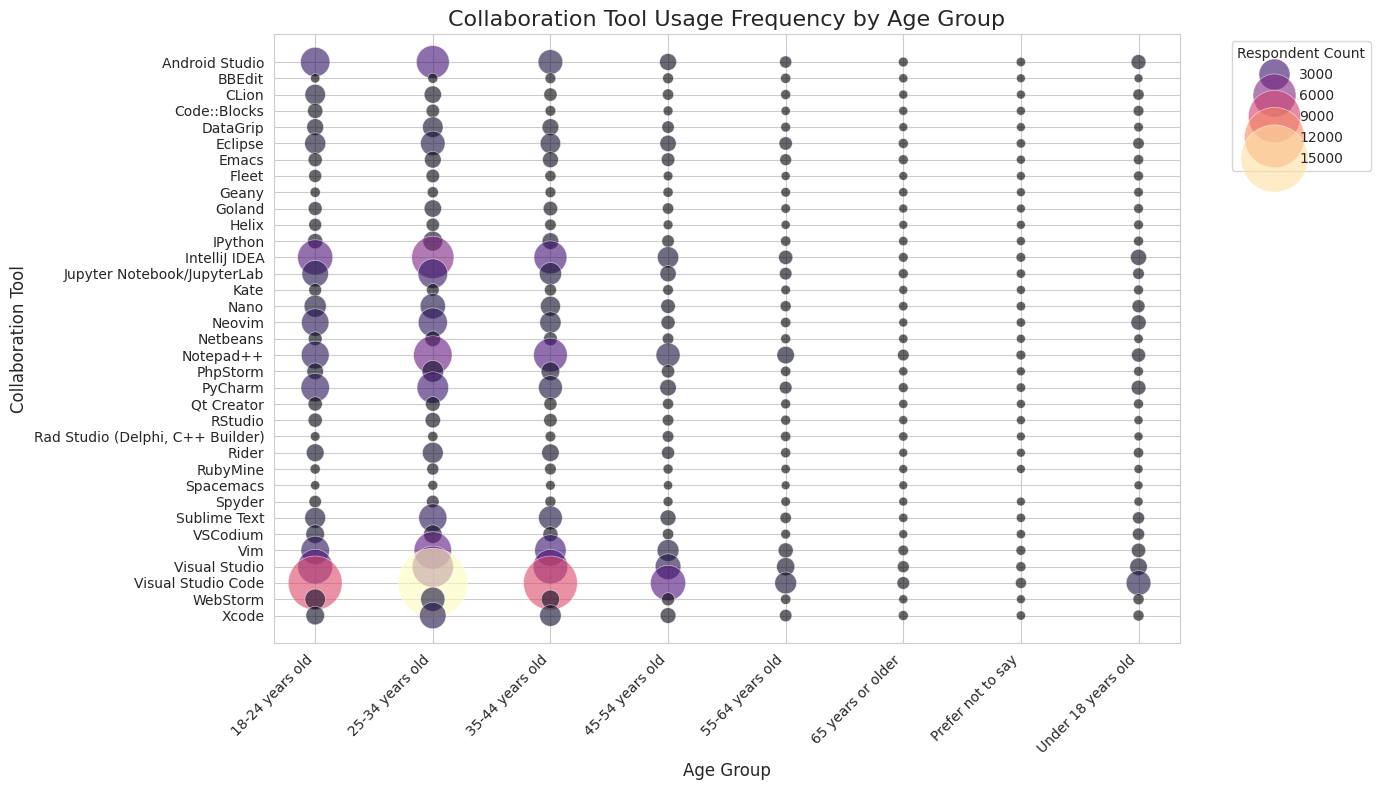

In [57]:
##Write your code here
# 3. Create the Bubble Chart
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# x: Age Group, y: Tool Name, size: UsageCount
ax = sns.scatterplot(
    data=collab_counts,
    x="Age", 
    y="Tool",
    size="UsageCount",
    sizes=(40, 2500),   # Adjust min/max bubble area for visual impact
    hue="UsageCount",    # Color bubbles by frequency for added depth
    palette="magma",     # High-contrast 2026-style palette
    alpha=0.6,
    legend='brief'
)

# 4. Final Formatting for 2026
plt.title("Collaboration Tool Usage Frequency by Age Group", fontsize=16)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Collaboration Tool", fontsize=12)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Adjust legend and layout
plt.legend(title="Respondent Count", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



In [61]:
# 2. Explode the multi-select 'WebframeWantToWorkWith' column
# This converts "React;Node.js" into two separate rows
df_exploded = df.assign(Framework=df['WebframeWantToWorkWith'].str.split(';')).explode('Framework')

In [62]:
# 3. Aggregate: Calculate mean satisfaction and respondent count per framework
bubble_sat = df_exploded.groupby('Framework').agg({
    'JobSat': 'mean',
    'ResponseId': 'count'  # Use a unique ID to count total respondents
}).reset_index().rename(columns={'ResponseId': 'Count'})

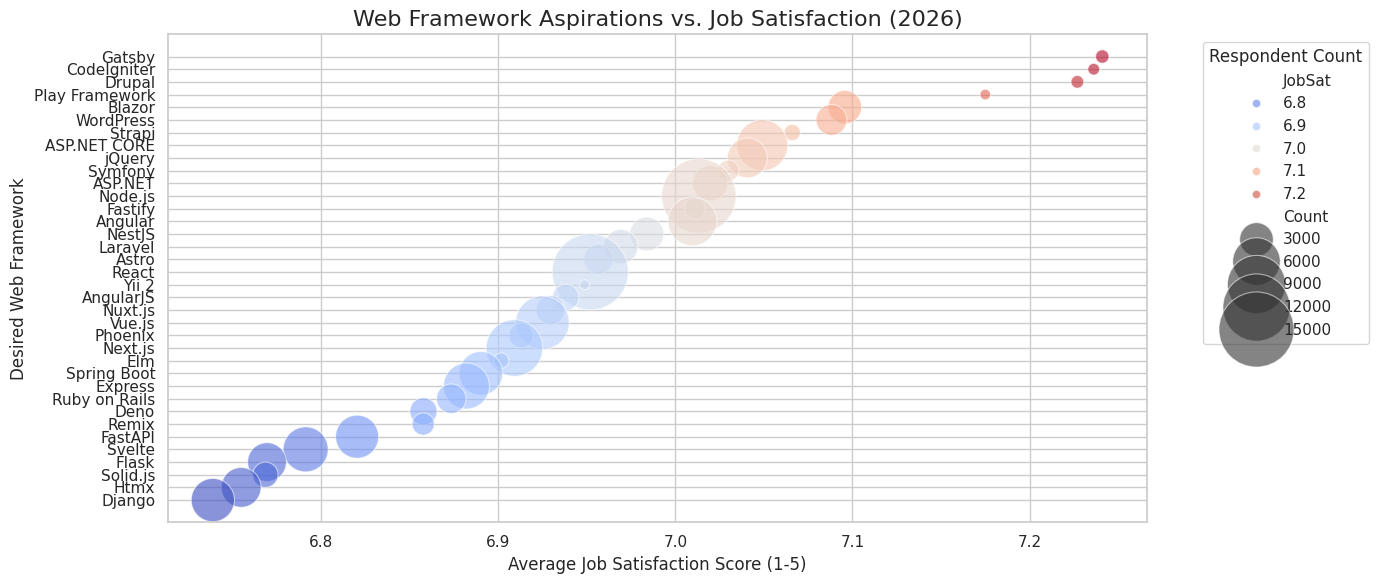

In [63]:
##Write your code here
# 4. Create the Bubble Plot
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# x: Average Satisfaction Score, y: Framework Name, size: Number of Respondents
ax = sns.scatterplot(
    data=bubble_sat.sort_values('JobSat', ascending=False),
    x="JobSat", 
    y="Framework",
    size="Count",          # Bubble size represents frequency
    sizes=(50, 3000),      # Scale the min/max bubble diameters
    hue="JobSat",       # Color also indicates satisfaction for dual-coding
    palette="coolwarm",    # Red for high satisfaction, blue for low
    alpha=0.6
)

# 5. Formatting for 2026 Standards
plt.title("Web Framework Aspirations vs. Job Satisfaction (2026)", fontsize=16)
plt.xlabel("Average Job Satisfaction Score (1-5)", fontsize=12)
plt.ylabel("Desired Web Framework", fontsize=12)
plt.legend(title="Respondent Count", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Admired Technologies Across Countries
- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).
- Use bubble size to represent the frequency of admiration.

In [64]:
# 1. Clean and Explode the technology column
# Respondents often select multiple: "Rust;Go;Zig"
df_exploded = df.assign(Language=df['LanguageAdmired'].str.split(';')).explode('Language')

In [65]:
# 2. Aggregation: Calculate frequency per Country and Language
# We'll filter for the Top 10 countries to keep the chart readable
top_countries = df['Country'].value_counts().nlargest(10).index
bubble_country = df_exploded[df_exploded['Country'].isin(top_countries)]
bubble_country = bubble_country.groupby(['Country', 'Language']).size().reset_index(name='Frequency')

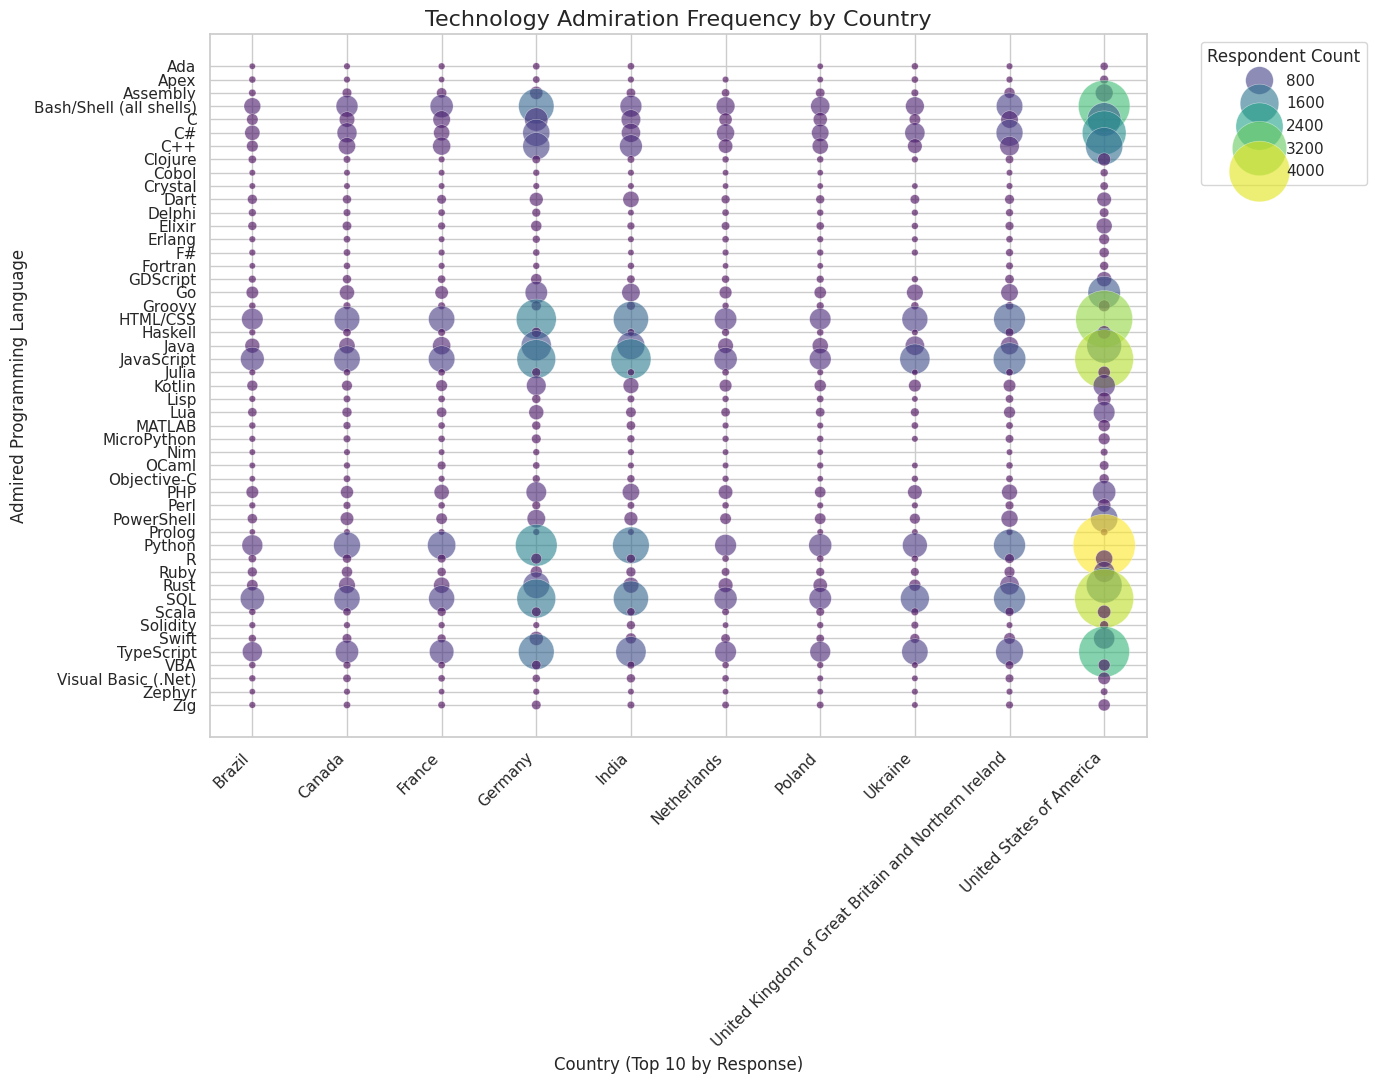

In [70]:
##Write your code here
# 3. Create the Bubble Chart
plt.figure(figsize=(14, 11))
sns.set_style("whitegrid")
# x: Country, y: Language, size: Frequency (Number of Admirers)
ax = sns.scatterplot(
    data=bubble_country,
    x="Country",
    y="Language",
    size="Frequency",      # Map bubble size to count
    sizes=(20, 2000),      # Control min/max bubble area
    hue="Frequency",       # Use color for secondary encoding
    palette="viridis",
    alpha=0.6
)
# 4. Final Formatting for 2026
plt.title("Technology Admiration Frequency by Country", fontsize=16)
plt.xlabel("Country (Top 10 by Response)", fontsize=12)
plt.ylabel("Admired Programming Language", fontsize=12)
# Rotate country names for readability
plt.xticks(rotation=45, ha='right')
# Position the legend to show the scale of admiration
plt.legend(title="Respondent Count", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
